# Audio Emotion Recognition — Experiments

Step-by-step training for all audio models × feature sets.
All models use **Bayesian hyperparameter search (optuna)** optimising **dev weighted F1**.

| Model | Feature sets | Search space | Trials |
|---|---|---|---|
| **LR** | egemaps, is10, emobase | C `[1e-3, 10]`, solver, max_iter | 30 |
| **SVM** | egemaps, is10, emobase | C `[1e-3, 10]`, tol, max_iter — `cv=prefit` on dev | 20 |
| **MLP** | egemaps, is10, emobase | hidden_1/2, dropout, lr, focal_gamma | 20 |

Run cells top-to-bottom. Each training cell is independent — re-run any single cell to retrain that model.

## Setup

In [1]:
import sys, json, importlib
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SRC = Path("../src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from config import METRICS_DIR, FEATURE_SETS

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

def load_metrics(pattern):
    """Load metrics JSONs. Use {} as placeholder for feature set key."""
    rows = []
    for key in FEATURE_SETS:
        p = METRICS_DIR / pattern.format(key)
        if p.exists():
            m = json.loads(p.read_text())
            rows.append({"feature_set": key,
                         "weighted_f1": m["weighted_f1"],
                         "macro_f1":    m["macro_f1"],
                         "accuracy":    m["accuracy"]})
    return pd.DataFrame(rows).set_index("feature_set") if rows else pd.DataFrame()

print("Setup done. Feature sets:", list(FEATURE_SETS))

Setup done. Feature sets: ['egemaps', 'is10', 'emobase']


---
## 1  Logistic Regression

Bayesian search (30 trials) over `C ∈ [1e-3, 10]`, `solver ∈ {lbfgs, saga}`, `max_iter ∈ [500, 3000]`.  
Objective: **dev weighted F1**.  
Best hyperparameters saved to `outputs/checkpoints/audio_lr_{feature_set}_hparams.json`.

In [2]:
import audio.lr.train as lr_module
importlib.reload(lr_module)
lr_module.main("egemaps")

Feature set : egemaps (eGeMAPSv02)
Loading features...
Scaler saved.
Bayesian search (30 trials, dev macro-F1)...


  0%|          | 0/30 [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warni

Best dev mF1 : 0.1882
Best params  : {'C': 0.001959526011514871, 'solver': 'saga', 'max_iter': 2500}
Training final model with best hyperparameters...


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Model saved.

--- Dev set ---
                   precision    recall  f1-score   support

          neutral       0.61      0.24      0.34       469
              joy       0.18      0.09      0.12       163
            anger       0.31      0.41      0.35       153
          sadness       0.22      0.37      0.28       111
          disgust       0.03      0.14      0.04        22
             fear       0.06      0.15      0.08        40
surprise_positive       0.10      0.16      0.12        70
surprise_negative       0.14      0.21      0.17        80

         accuracy                           0.24      1108
        macro avg       0.20      0.22      0.19      1108
     weighted avg       0.37      0.24      0.26      1108

--- Test set ---

Model: audio_lr_egemaps
  Weighted F1 : 0.2497
  Macro F1    : 0.1690
  Accuracy    : 0.2199
                   precision    recall  f1-score   support

          neutral       0.64      0.21      0.32      1256
              joy       0.19 

In [3]:
importlib.reload(lr_module)
lr_module.main("is10")

Feature set : is10 (IS10)
Loading features...
[WARN] Dropped 6 row(s) with NaN values from train_is10.parquet (train/is10).
[WARN] Dropped 2 row(s) with NaN values from dev_is10.parquet (dev/is10).
Scaler saved.
Bayesian search (30 trials, dev macro-F1)...


  0%|          | 0/30 [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-

Best dev mF1 : 0.1809
Best params  : {'C': 0.0012355217597810556, 'solver': 'saga', 'max_iter': 3000}
Training final model with best hyperparameters...
Model saved.

--- Dev set ---
                   precision    recall  f1-score   support

          neutral       0.57      0.16      0.25       469
              joy       0.23      0.18      0.20       163
            anger       0.33      0.43      0.37       152
          sadness       0.20      0.27      0.23       111
          disgust       0.02      0.14      0.04        22
             fear       0.03      0.10      0.05        40
surprise_positive       0.09      0.17      0.12        69
surprise_negative       0.16      0.20      0.18        80

         accuracy                           0.22      1106
        macro avg       0.20      0.21      0.18      1106
     weighted avg       0.36      0.22      0.24      1106

--- Test set ---

Model: audio_lr_is10
  Weighted F1 : 0.2479
  Macro F1    : 0.1732
  Accuracy    : 0.2157

In [4]:
importlib.reload(lr_module)
lr_module.main("emobase")

Feature set : emobase (emobase)
Loading features...
Scaler saved.
Bayesian search (30 trials, dev macro-F1)...


  0%|          | 0/30 [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules

Best dev mF1 : 0.1889
Best params  : {'C': 0.0014272758626179937, 'solver': 'saga', 'max_iter': 2000}
Training final model with best hyperparameters...
Model saved.

--- Dev set ---
                   precision    recall  f1-score   support

          neutral       0.63      0.15      0.24       469
              joy       0.21      0.14      0.17       163
            anger       0.32      0.45      0.38       153
          sadness       0.24      0.30      0.26       111
          disgust       0.02      0.14      0.04        22
             fear       0.06      0.17      0.09        40
surprise_positive       0.07      0.16      0.10        70
surprise_negative       0.20      0.30      0.24        80

         accuracy                           0.22      1108
        macro avg       0.22      0.23      0.19      1108
     weighted avg       0.39      0.22      0.23      1108

--- Test set ---

Model: audio_lr_emobase
  Weighted F1 : 0.2195
  Macro F1    : 0.1534
  Accuracy    : 0.1

### LR — Results

In [5]:
lr_results = load_metrics("audio_lr_{}.json")
display(lr_results.style.highlight_max(axis=0, color="#d4f1c4").format("{:.4f}"))

,weighted_f1,macro_f1,accuracy
feature_set,,,
egemaps,0.2497,0.1690,0.2199
is10,0.2479,0.1732,0.2157
emobase,0.2195,0.1534,0.1881


---
## 2  SVM (LinearSVC + Platt calibration)

Bayesian search (20 trials) over `C`, `tol`, `max_iter`.  
`cv='prefit'`: trained on full train set, calibrated on dev — no calibration folds.  
Objective: **dev weighted F1**.

In [6]:
import audio.svm.train as svm_module
importlib.reload(svm_module)
svm_module.main("egemaps")

Feature set : egemaps (eGeMAPSv02)
Loading features...
Scaler saved.
Bayesian search (20 trials, dev macro-F1)...


  0%|          | 0/20 [00:00<?, ?it/s]

Best dev mF1 : 0.1434
Best params  : {'C': 0.7746080211942609, 'tol': 7.109576294541398e-05, 'max_iter': 2500}
Training final model with best hyperparameters...
Model saved.

--- Dev set ---
                   precision    recall  f1-score   support

          neutral       0.46      0.95      0.62       469
              joy       0.09      0.01      0.01       163
            anger       0.37      0.28      0.32       153
          sadness       0.62      0.05      0.08       111
          disgust       0.00      0.00      0.00        22
             fear       0.00      0.00      0.00        40
surprise_positive       0.00      0.00      0.00        70
surprise_negative       0.38      0.06      0.11        80

         accuracy                           0.45      1108
        macro avg       0.24      0.17      0.14      1108
     weighted avg       0.35      0.45      0.33      1108

--- Test set ---

Model: audio_svm_egemaps
  Weighted F1 : 0.3548
  Macro F1    : 0.1201
  Accurac

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

Softmax saved → shape (2610, 8)

Comparison across feature sets (SVM, mF1):
  egemaps     wF1 0.1201 ←


In [7]:
importlib.reload(svm_module)
svm_module.main("is10")

Feature set : is10 (IS10)
Loading features...
[WARN] Dropped 6 row(s) with NaN values from train_is10.parquet (train/is10).
[WARN] Dropped 2 row(s) with NaN values from dev_is10.parquet (dev/is10).
Scaler saved.
Bayesian search (20 trials, dev macro-F1)...


  0%|          | 0/20 [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/zeus/miniconda

Best dev mF1 : 0.1161
Best params  : {'C': 0.0012350877142584726, 'tol': 0.00010064717994056096, 'max_iter': 1000}
Training final model with best hyperparameters...
Model saved.

--- Dev set ---
                   precision    recall  f1-score   support

          neutral       0.45      0.97      0.61       469
              joy       0.29      0.01      0.02       163
            anger       0.41      0.18      0.25       152
          sadness       1.00      0.01      0.02       111
          disgust       0.00      0.00      0.00        22
             fear       0.00      0.00      0.00        40
surprise_positive       0.00      0.00      0.00        69
surprise_negative       0.20      0.01      0.02        80

         accuracy                           0.44      1106
        macro avg       0.29      0.15      0.12      1106
     weighted avg       0.40      0.44      0.30      1106

--- Test set ---

Model: audio_svm_is10
  Weighted F1 : 0.3395
  Macro F1    : 0.1058
  Accura

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

Softmax saved → shape (2610, 8)

Comparison across feature sets (SVM, mF1):
  egemaps     wF1 0.1201
  is10        wF1 0.1058 ←


In [8]:
importlib.reload(svm_module)
svm_module.main("emobase")

Feature set : emobase (emobase)
Loading features...
Scaler saved.
Bayesian search (20 trials, dev macro-F1)...


  0%|          | 0/20 [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Best dev mF1 : 0.1066
Best params  : {'C': 0.0011906993082973114, 'tol': 0.0033713490173047905, 'max_iter': 2000}
Training final model with best hyperparameters...
Model saved.

--- Dev set ---
                   precision    recall  f1-score   support

          neutral       0.44      0.96      0.60       469
              joy       0.20      0.01      0.02       163
            anger       0.31      0.14      0.19       153
          sadness       0.67      0.02      0.04       111
          disgust       0.00      0.00      0.00        22
             fear       0.00      0.00      0.00        40
surprise_positive       0.00      0.00      0.00        70
surprise_negative       0.00      0.00      0.00        80

         accuracy                           0.43      1108
        macro avg       0.20      0.14      0.11      1108
     weighted avg       0.33      0.43      0.29      1108

--- Test set ---

Model: audio_svm_emobase
  Weighted F1 : 0.3410
  Macro F1    : 0.1067
  Accu

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

Softmax saved → shape (2610, 8)

Comparison across feature sets (SVM, mF1):
  egemaps     wF1 0.1201
  is10        wF1 0.1058
  emobase     wF1 0.1067 ←


### SVM — Results

In [9]:
svm_results = load_metrics("audio_svm_{}.json")
display(svm_results.style.highlight_max(axis=0, color="#d4f1c4").format("{:.4f}"))

,weighted_f1,macro_f1,accuracy
feature_set,,,
egemaps,0.3548,0.1201,0.4851
is10,0.3395,0.1058,0.4874
emobase,0.3410,0.1067,0.4866


---
## 3  MLP

Bayesian search (20 trials) over architecture `[hidden_1, hidden_2]`, `dropout`, `lr`, `focal_gamma`.  
FocalLoss with balanced class weights. Early stopping patience=10 on **dev weighted F1**.  
Final training: max 100 epochs with ReduceLROnPlateau (factor=0.5, patience=5).  
Outputs to `outputs/checkpoints/` (scaler, best checkpoint, hparams) — one set per feature set.

In [10]:
import audio.mlp.train as mlp_module
importlib.reload(mlp_module)
mlp_module.main("egemaps")

Device      : cpu
Feature set : egemaps (eGeMAPSv02)
Loading features...
Scaler saved → audio_mlp_egemaps_scaler.pkl

Bayesian search (20 trials, dev macro-F1)...


  0%|          | 0/20 [00:00<?, ?it/s]

Best dev mF1 : 0.1527
Best params  : {'hidden_1': 256, 'hidden_2': 128, 'dropout': 0.3292914326871103, 'lr': 0.0012194982531971237, 'focal_gamma': 1.1221794786771562}
Hparams saved → audio_mlp_egemaps_hparams.json

Final training (max 100 epochs, patience=10)...
Best dev mF1 : 0.1431
Checkpoint   → audio_mlp_egemaps_best.pt

Model: audio_mlp_egemaps
  Weighted F1 : 0.1067
  Macro F1    : 0.1405
  Accuracy    : 0.1395
                   precision    recall  f1-score   support

          neutral       0.75      0.00      0.00      1256
              joy       0.21      0.15      0.18       402
            anger       0.27      0.34      0.31       345
          sadness       0.15      0.42      0.23       208
          disgust       0.05      0.24      0.08        68
             fear       0.02      0.12      0.03        50
surprise_positive       0.09      0.27      0.13       119
surprise_negative       0.12      0.24      0.16       162

         accuracy                           0.

In [11]:
importlib.reload(mlp_module)
mlp_module.main("is10")

Device      : cpu
Feature set : is10 (IS10)
Loading features...
[WARN] Dropped 6 row(s) with NaN values from train_is10.parquet (train/is10).
[WARN] Dropped 2 row(s) with NaN values from dev_is10.parquet (dev/is10).
Scaler saved → audio_mlp_is10_scaler.pkl

Bayesian search (20 trials, dev macro-F1)...


  0%|          | 0/20 [00:00<?, ?it/s]

Best dev mF1 : 0.1555
Best params  : {'hidden_1': 256, 'hidden_2': 64, 'dropout': 0.3343154038810235, 'lr': 0.00014066422434020742, 'focal_gamma': 1.5057610510013644}
Hparams saved → audio_mlp_is10_hparams.json

Final training (max 100 epochs, patience=10)...
Best dev mF1 : 0.1505
Checkpoint   → audio_mlp_is10_best.pt

Model: audio_mlp_is10
  Weighted F1 : 0.0947
  Macro F1    : 0.1256
  Accuracy    : 0.1249
                   precision    recall  f1-score   support

          neutral       0.62      0.01      0.01      1256
              joy       0.14      0.07      0.10       402
            anger       0.26      0.36      0.30       345
          sadness       0.16      0.35      0.22       208
          disgust       0.05      0.21      0.07        68
             fear       0.03      0.20      0.05        50
surprise_positive       0.07      0.27      0.11       119
surprise_negative       0.10      0.23      0.14       162

         accuracy                           0.12      2

In [12]:
importlib.reload(mlp_module)
mlp_module.main("emobase")

Device      : cpu
Feature set : emobase (emobase)
Loading features...
Scaler saved → audio_mlp_emobase_scaler.pkl

Bayesian search (20 trials, dev macro-F1)...


  0%|          | 0/20 [00:00<?, ?it/s]

Best dev mF1 : 0.1639
Best params  : {'hidden_1': 128, 'hidden_2': 32, 'dropout': 0.3374280975221521, 'lr': 0.00011831179860048076, 'focal_gamma': 1.1422797796707473}
Hparams saved → audio_mlp_emobase_hparams.json

Final training (max 100 epochs, patience=10)...
Best dev mF1 : 0.1570
Checkpoint   → audio_mlp_emobase_best.pt

Model: audio_mlp_emobase
  Weighted F1 : 0.1049
  Macro F1    : 0.1353
  Accuracy    : 0.1414
                   precision    recall  f1-score   support

          neutral       0.42      0.01      0.01      1256
              joy       0.23      0.14      0.18       402
            anger       0.22      0.35      0.27       345
          sadness       0.15      0.41      0.22       208
          disgust       0.06      0.25      0.10        68
             fear       0.02      0.08      0.03        50
surprise_positive       0.08      0.14      0.10       119
surprise_negative       0.11      0.38      0.17       162

         accuracy                           0.

### MLP — Results

In [13]:
mlp_results = load_metrics("audio_mlp_{}.json")
display(mlp_results.style.highlight_max(axis=0, color="#d4f1c4").format("{:.4f}"))

,weighted_f1,macro_f1,accuracy
feature_set,,,
egemaps,0.1067,0.1405,0.1395
is10,0.0947,0.1256,0.1249
emobase,0.1049,0.1353,0.1414


---
## 4  Overall Comparison

In [14]:
rows = []

for model_tag, pattern in [("LR", "audio_lr_{}.json"), ("SVM", "audio_svm_{}.json"), ("MLP", "audio_mlp_{}.json")]:
    for key in FEATURE_SETS:
        p = METRICS_DIR / pattern.format(key)
        if p.exists():
            m = json.loads(p.read_text())
            rows.append({"model": model_tag, "features": key,
                         "weighted_f1": m["weighted_f1"],
                         "macro_f1":    m["macro_f1"],
                         "accuracy":    m["accuracy"]})

all_results = pd.DataFrame(rows)
display(
    all_results.sort_values("weighted_f1", ascending=False)
               .reset_index(drop=True)
               .style
               .highlight_max(subset=["weighted_f1", "macro_f1"], color="#d4f1c4")
               .format({"weighted_f1": "{:.4f}", "macro_f1": "{:.4f}", "accuracy": "{:.4f}"})
)

,model,features,weighted_f1,macro_f1,accuracy
0,SVM,egemaps,0.3548,0.1201,0.4851
1,SVM,emobase,0.3410,0.1067,0.4866
2,SVM,is10,0.3395,0.1058,0.4874
3,LR,egemaps,0.2497,0.1690,0.2199
4,LR,is10,0.2479,0.1732,0.2157
5,LR,emobase,0.2195,0.1534,0.1881
6,MLP,egemaps,0.1067,0.1405,0.1395
7,MLP,emobase,0.1049,0.1353,0.1414
8,MLP,is10,0.0947,0.1256,0.1249


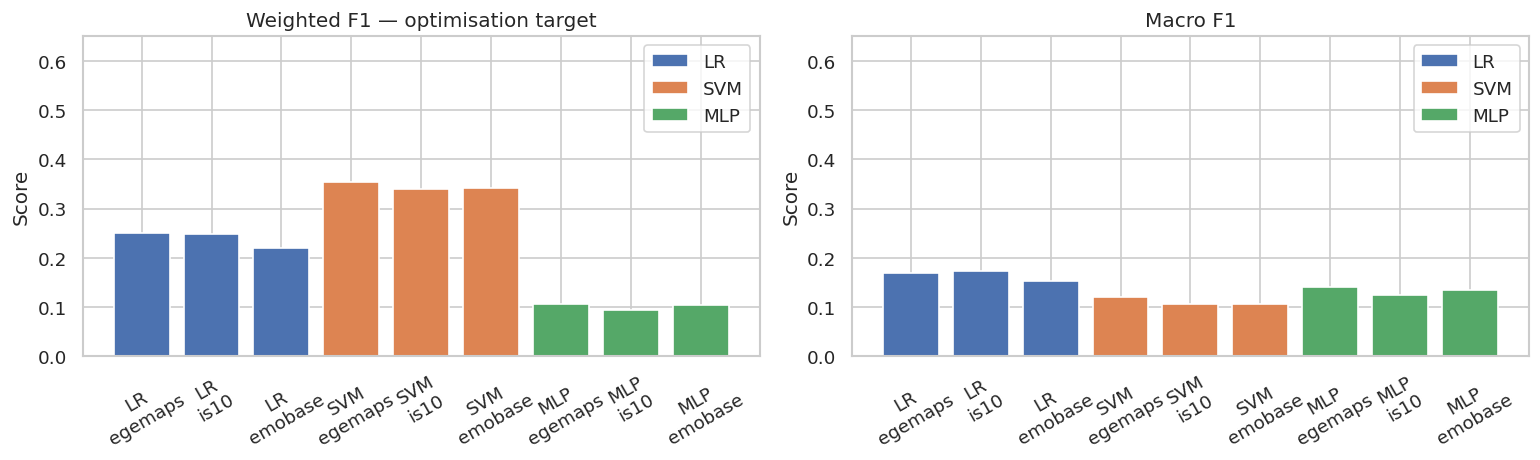

In [15]:
colors = {"LR": "#4C72B0", "SVM": "#DD8452", "MLP": "#55A868"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, title in zip(
    axes,
    ["weighted_f1", "macro_f1"],
    ["Weighted F1 — optimisation target", "Macro F1"],
):
    seen_labels = set()
    for _, row in all_results.iterrows():
        label = row["model"] if row["model"] not in seen_labels else None
        ax.bar(
            f"{row['model']}\n{row['features']}",
            row[metric],
            color=colors[row["model"]],
            label=label,
        )
        seen_labels.add(row["model"])
    ax.set_title(title)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 0.65)
    ax.tick_params(axis="x", rotation=30)
    ax.legend()

plt.tight_layout()
plt.savefig("../outputs/plots/audio_model_comparison.png", bbox_inches="tight")
plt.show()

### Per-class breakdown — best model by weighted F1

In [16]:
best_row  = all_results.loc[all_results["weighted_f1"].idxmax()]
model_key = best_row["model"].lower()
fs_key    = best_row["features"]

best_tag  = f"audio_{model_key}_{fs_key}"

print(f"Best model : {best_tag}")
print(f"Weighted F1: {best_row['weighted_f1']:.4f}  |  Macro F1: {best_row['macro_f1']:.4f}")

m = json.loads((METRICS_DIR / f"{best_tag}.json").read_text())
per_class = pd.DataFrame(m["per_class"]).T[["precision", "recall", "f1", "support"]]
display(
    per_class.style
             .background_gradient(subset=["f1"], cmap="RdYlGn", vmin=0, vmax=0.7)
             .format({"precision": "{:.3f}", "recall": "{:.3f}",
                      "f1": "{:.3f}", "support": "{:.0f}"})
)

Best model : audio_svm_egemaps
Weighted F1: 0.3548  |  Macro F1: 0.1201


,precision,recall,f1,support
neutral,0.507,0.955,0.662,1256
joy,0.280,0.017,0.033,402
anger,0.292,0.157,0.204,345
sadness,0.143,0.010,0.018,208
disgust,0.000,0.000,0.000,68
fear,0.000,0.000,0.000,50
surprise_positive,0.000,0.000,0.000,119
surprise_negative,0.210,0.025,0.044,162
